# 01 — Data Profiling & Quality Assessment
**Project:** LA 2028 Olympic Games Strategic Analysis  
**Analyst:** Shabeeb | SportsFanatics Consulting  
**Dataset:** `athlete_events.csv`  
**Goal:** Understand the structure, completeness, and quality of the raw dataset before any analysis.


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
import logging
import warnings
warnings.filterwarnings('ignore')

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
logger = logging.getLogger(__name__)

# Paths
BASE_DIR = Path('..') 
RAW_DATA  = BASE_DIR / 'data' / 'raw' / 'athlete_events.csv'
OUT_TABLES = BASE_DIR / 'outputs' / 'tables'
OUT_FIGS   = BASE_DIR / 'outputs' / 'figures'

# Olympic color palette
OLY_COLORS = {
    'blue':   '#0085C7',
    'yellow': '#F4C300',
    'black':  '#000000',
    'green':  '#009F6B',
    'red':    '#DF0024',
    'bg':     '#F8F9FA'
}

logger.info('Setup complete.')

Matplotlib is building the font cache; this may take a moment.


INFO: Setup complete.


## 1. Load Data

In [2]:
try:
    df = pd.read_csv(RAW_DATA)
    logger.info(f'Loaded {RAW_DATA.name} — {df.shape[0]:,} rows x {df.shape[1]} columns')
except FileNotFoundError:
    logger.error(f'File not found: {RAW_DATA}')
    raise

df.head(10)

INFO: Loaded athlete_events.csv — 271,116 rows x 15 columns


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
5,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,"Speed Skating Women's 1,000 metres",NaN
6,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,Speed Skating Women's 500 metres,NaN
7,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,"Speed Skating Women's 1,000 metres",NaN
8,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,Speed Skating Women's 500 metres,NaN
9,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,"Speed Skating Women's 1,000 metres",NaN


## 2. Basic Shape & Dtypes

In [3]:
print(f'Shape       : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print()
print('Column dtypes:')
print(df.dtypes)

Shape       : 271,116 rows × 15 columns
Memory usage: 186.4 MB

Column dtypes:
ID          int64
Name          str
Sex           str
Age       float64
Height    float64
Weight    float64
Team          str
NOC           str
Games         str
Year        int64
Season        str
City          str
Sport         str
Event         str
Medal         str
dtype: object


## 3. Null Value Analysis

In [4]:
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(2)

null_summary = pd.DataFrame({
    'Missing Count': null_counts,
    'Missing %': null_pct
}).sort_values('Missing %', ascending=False)

print('Null value summary:')
display(null_summary)

# Save
null_summary.to_csv(OUT_TABLES / 'profiling_null_summary.csv')
logger.info('Saved null_summary to outputs/tables/')

Null value summary:


,Missing Count,Missing %
Medal,231333,85.33
Weight,62875,23.19
Height,60171,22.19
Age,9474,3.49
ID,0,0.00
Name,0,0.00
Sex,0,0.00
Team,0,0.00
NOC,0,0.00
Games,0,0.00


INFO: Saved null_summary to outputs/tables/


In [5]:
# Visualise missing data
cols_with_nulls = null_summary[null_summary['Missing %'] > 0]

fig = px.bar(
    cols_with_nulls.reset_index(),
    x='index', y='Missing %',
    title='Missing Data by Column',
    labels={'index': 'Column', 'Missing %': 'Missing (%)'},
    color='Missing %',
    color_continuous_scale=[[0, OLY_COLORS['blue']], [1, OLY_COLORS['red']]],
    template='plotly_white',
    width=900, height=500
)
fig.update_layout(font_family='Arial', title_font_size=18)
fig.write_html(OUT_FIGS / 'profiling_bar_missingData.html')
fig.show()
logger.info('Saved missing data chart.')

INFO: Saved missing data chart.


## 4. Duplicate Row Check

In [6]:
n_dupes = df.duplicated().sum()
print(f'Fully duplicate rows: {n_dupes:,} ({n_dupes/len(df)*100:.2f}%)')

if n_dupes > 0:
    logger.warning(f'{n_dupes} duplicate rows found — review before analysis.')
    display(df[df.duplicated(keep=False)].head(10))
else:
    logger.info('No duplicate rows found.')

Fully duplicate rows: 1,385 (0.51%)


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
1251,704,Dsir Antoine Acket,M,27.0,NaN,NaN,Belgium,BEL,1932 Summer,1932,Summer,Los Angeles,Art Competitions,"Art Competitions Mixed Painting, Unknown Event",NaN
1252,704,Dsir Antoine Acket,M,27.0,NaN,NaN,Belgium,BEL,1932 Summer,1932,Summer,Los Angeles,Art Competitions,"Art Competitions Mixed Painting, Unknown Event",NaN
4281,2449,William Truman Aldrich,M,48.0,NaN,NaN,United States,USA,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Painting, Drawings And ...",NaN
4282,2449,William Truman Aldrich,M,48.0,NaN,NaN,United States,USA,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Painting, Drawings And ...",NaN
4283,2449,William Truman Aldrich,M,48.0,NaN,NaN,United States,USA,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Painting, Drawings And ...",NaN
4861,2777,Hermann Reinhard Alker,M,43.0,NaN,NaN,Germany,GER,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Architecture, Designs F...",NaN
4862,2777,Hermann Reinhard Alker,M,43.0,NaN,NaN,Germany,GER,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Architecture, Designs F...",NaN
4863,2777,Hermann Reinhard Alker,M,43.0,NaN,NaN,Germany,GER,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Architecture, Architect...",NaN
4864,2777,Hermann Reinhard Alker,M,43.0,NaN,NaN,Germany,GER,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Architecture, Architect...",NaN
4866,2777,Hermann Reinhard Alker,M,51.0,NaN,NaN,Germany,GER,1936 Summer,1936,Summer,Berlin,Art Competitions,"Art Competitions Mixed Architecture, Unknown E...",NaN


## 5. Value Ranges & Descriptive Stats

In [7]:
# Numeric columns
numeric_summary = df.describe(percentiles=[.05, .25, .5, .75, .95]).T
print('Numeric column statistics:')
display(numeric_summary)

numeric_summary.to_csv(OUT_TABLES / 'profiling_numeric_summary.csv')
logger.info('Saved numeric summary.')

Numeric column statistics:


,count,mean,std,min,5%,25%,50%,75%,95%,max
ID,271116.0,68248.954396,39022.286345,1.0,7347.75,34643.0,68205.0,102097.25,128978.0,135571.0
Age,261642.0,25.556898,6.393561,10.0,18.00,21.0,24.0,28.00,37.0,97.0
Height,210945.0,175.338970,10.518462,127.0,158.00,168.0,175.0,183.00,193.0,226.0
Weight,208241.0,70.702393,14.348020,25.0,50.00,60.0,70.0,79.00,95.0,214.0
Year,271116.0,1978.378480,29.877632,1896.0,1920.00,1960.0,1988.0,2002.00,2016.0,2016.0


INFO: Saved numeric summary.


In [8]:
# Categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_summary = pd.DataFrame({
    'Unique Values': [df[c].nunique() for c in cat_cols],
    'Top Value':     [df[c].mode()[0] if not df[c].mode().empty else 'N/A' for c in cat_cols],
    'Top Freq':      [df[c].value_counts().iloc[0] if df[c].notna().any() else 0 for c in cat_cols]
}, index=cat_cols)

print('Categorical column summary:')
display(cat_summary)

cat_summary.to_csv(OUT_TABLES / 'profiling_categorical_summary.csv')
logger.info('Saved categorical summary.')

Categorical column summary:


,Unique Values,Top Value,Top Freq
Name,134732,Robert Tait McKenzie,58
Sex,2,M,196594
Team,1184,United States,17847
NOC,230,USA,18853
Games,51,2000 Summer,13821
Season,2,Summer,222552
City,42,London,22426
Sport,66,Athletics,38624
Event,765,Football Men's Football,5733
Medal,3,Gold,13372


INFO: Saved categorical summary.


## 6. Year & Season Coverage

In [9]:
print(f'Year range : {df["Year"].min()} – {df["Year"].max()}')
print(f'Seasons    : {df["Season"].unique()}')
print(f'Total Games editions: {df["Games"].nunique()}')
print()
print('Records per Season:')
print(df['Season'].value_counts())

Year range : 1896 – 2016
Seasons    : <StringArray>
['Summer', 'Winter']
Length: 2, dtype: str
Total Games editions: 51

Records per Season:
Season
Summer    222552
Winter     48564
Name: count, dtype: int64


In [10]:
# Athletes per Games edition
athletes_per_games = (
    df.groupby(['Year', 'Season'])['ID']
    .nunique()
    .reset_index()
    .rename(columns={'ID': 'Unique Athletes'})
    .sort_values('Year')
)

fig = px.line(
    athletes_per_games,
    x='Year', y='Unique Athletes',
    color='Season',
    markers=True,
    title='Unique Athletes per Olympic Games Edition',
    color_discrete_map={'Summer': OLY_COLORS['blue'], 'Winter': OLY_COLORS['red']},
    template='plotly_white',
    width=1200, height=600
)
fig.update_layout(font_family='Arial', title_font_size=18)
fig.write_html(OUT_FIGS / 'profiling_line_athletesPerGames.html')
fig.show()
logger.info('Saved athletes per games chart.')

INFO: Saved athletes per games chart.


## 7. Medal Distribution

In [11]:
medal_counts = df['Medal'].value_counts(dropna=False)
print('Medal value counts (including NA = no medal):')
print(medal_counts)
print(f'\nMedal win rate: {(df["Medal"].notna().sum() / len(df) * 100):.1f}% of all entries')

Medal value counts (including NA = no medal):
Medal
NaN       231333
Gold       13372
Bronze     13295
Silver     13116
Name: count, dtype: int64

Medal win rate: 14.7% of all entries


In [12]:
medal_only = df[df['Medal'].notna()]

fig = px.pie(
    medal_only,
    names='Medal',
    title='Medal Distribution (Gold / Silver / Bronze)',
    color='Medal',
    color_discrete_map={
        'Gold':   OLY_COLORS['yellow'],
        'Silver': '#C0C0C0',
        'Bronze': '#CD7F32'
    },
    template='plotly_white',
    width=700, height=500
)
fig.update_layout(font_family='Arial', title_font_size=18)
fig.write_html(OUT_FIGS / 'profiling_pie_medalDistribution.html')
fig.show()
logger.info('Saved medal distribution chart.')

INFO: Saved medal distribution chart.


## 8. Sport & NOC Coverage

In [13]:
print(f'Unique Sports : {df["Sport"].nunique()}')
print(f'Unique Events : {df["Event"].nunique()}')
print(f'Unique NOCs   : {df["NOC"].nunique()}')
print(f'Unique Athletes: {df["ID"].nunique():,}')
print()
print('Top 15 Sports by entries:')
display(df['Sport'].value_counts().head(15))

Unique Sports : 66
Unique Events : 765
Unique NOCs   : 230
Unique Athletes: 135,571

Top 15 Sports by entries:


Sport
Athletics               38624
Gymnastics              26707
Swimming                23195
Shooting                11448
Cycling                 10859
Fencing                 10735
Rowing                  10595
Cross Country Skiing     9133
Alpine Skiing            8829
Wrestling                7154
Football                 6745
Sailing                  6586
Equestrianism            6344
Canoeing                 6171
Boxing                   6047
Name: count, dtype: int64

In [14]:
# Top 20 NOCs by participation
top_nocs = (
    df.groupby('NOC')['ID'].nunique()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
    .rename(columns={'ID': 'Unique Athletes'})
)

fig = px.bar(
    top_nocs,
    x='NOC', y='Unique Athletes',
    title='Top 20 NOCs by Unique Athletes (All-Time)',
    color='Unique Athletes',
    color_continuous_scale=[[0, OLY_COLORS['blue']], [1, OLY_COLORS['yellow']]],
    template='plotly_white',
    width=1200, height=600
)
fig.update_layout(font_family='Arial', title_font_size=18)
fig.write_html(OUT_FIGS / 'profiling_bar_topNOCsParticipation.html')
fig.show()
logger.info('Saved top NOCs chart.')

INFO: Saved top NOCs chart.


## 9. Gender Distribution Over Time

In [15]:
gender_over_time = (
    df[df['Season'] == 'Summer']
    .groupby(['Year', 'Sex'])['ID']
    .nunique()
    .reset_index()
    .rename(columns={'ID': 'Athletes', 'Sex': 'Gender'})
)
gender_over_time['Gender'] = gender_over_time['Gender'].map({'M': 'Male', 'F': 'Female'})

fig = px.area(
    gender_over_time,
    x='Year', y='Athletes',
    color='Gender',
    title='Gender Participation Over Time — Summer Olympics',
    color_discrete_map={'Male': OLY_COLORS['blue'], 'Female': OLY_COLORS['red']},
    template='plotly_white',
    width=1200, height=600
)
fig.update_layout(font_family='Arial', title_font_size=18)
fig.write_html(OUT_FIGS / 'profiling_area_genderOverTime.html')
fig.show()
logger.info('Saved gender over time chart.')

INFO: Saved gender over time chart.


## 10. Age / Height / Weight Distributions

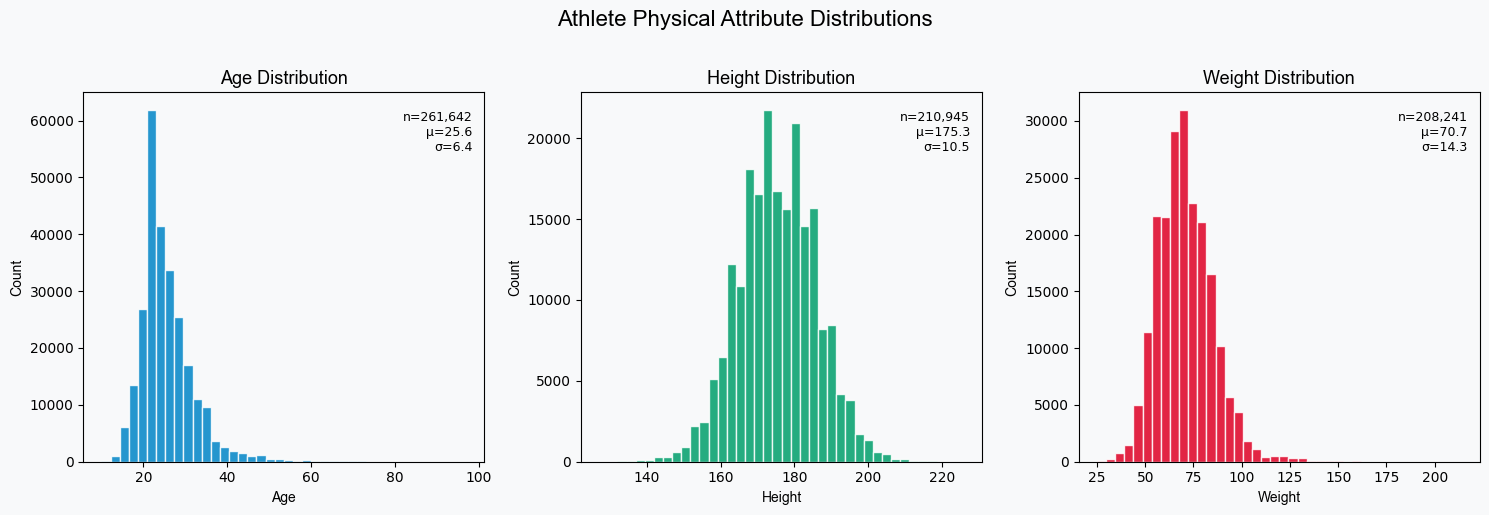

INFO: Saved attribute distributions chart.


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor(OLY_COLORS['bg'])

for ax, col, color in zip(axes, ['Age', 'Height', 'Weight'],
                          [OLY_COLORS['blue'], OLY_COLORS['green'], OLY_COLORS['red']]):
    data = df[col].dropna()
    ax.hist(data, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{col} Distribution', fontsize=13, fontname='Arial')
    ax.set_xlabel(col, fontname='Arial')
    ax.set_ylabel('Count', fontname='Arial')
    ax.set_facecolor(OLY_COLORS['bg'])
    ax.text(0.97, 0.95, f'n={len(data):,}\nμ={data.mean():.1f}\nσ={data.std():.1f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9)

plt.suptitle('Athlete Physical Attribute Distributions', fontsize=16, fontname='Arial', y=1.02)
plt.tight_layout()
plt.savefig(OUT_FIGS / 'profiling_hist_athleteAttributes.png', dpi=300, bbox_inches='tight')
plt.show()
logger.info('Saved attribute distributions chart.')

## 11. Data Quality Notes

In [17]:
# Flag any anomalies
anomalies = []

# Age outliers
age_outliers = df[(df['Age'] < 10) | (df['Age'] > 80)].dropna(subset=['Age'])
if not age_outliers.empty:
    anomalies.append(f'Age outliers (<10 or >80): {len(age_outliers)} rows')
    print('Age outliers:')
    display(age_outliers[['Name','Age','Sport','Year']].head(10))

# Height outliers
height_outliers = df[(df['Height'] < 130) | (df['Height'] > 230)].dropna(subset=['Height'])
if not height_outliers.empty:
    anomalies.append(f'Height outliers (<130 or >230 cm): {len(height_outliers)} rows')
    print('Height outliers:')
    display(height_outliers[['Name','Height','Sport','Year']].head(10))

# Weight outliers
weight_outliers = df[(df['Weight'] < 30) | (df['Weight'] > 200)].dropna(subset=['Weight'])
if not weight_outliers.empty:
    anomalies.append(f'Weight outliers (<30 or >200 kg): {len(weight_outliers)} rows')
    print('Weight outliers:')
    display(weight_outliers[['Name','Weight','Sport','Year']].head(10))

# Unexpected Medal values
valid_medals = {'Gold', 'Silver', 'Bronze'}
bad_medals = df[df['Medal'].notna() & ~df['Medal'].isin(valid_medals)]
if not bad_medals.empty:
    anomalies.append(f'Unexpected Medal values: {bad_medals["Medal"].unique()}')

if not anomalies:
    print('No critical anomalies detected.')
else:
    print('\nAnomalies flagged:')
    for a in anomalies:
        print(f'  ⚠ {a}')

Age outliers:


,Name,Age,Sport,Year
9371,George Denholm Armour,84.0,Art Competitions,1948
60861,Thomas Cowperthwait Eakins,88.0,Art Competitions,1932
60862,Thomas Cowperthwait Eakins,88.0,Art Competitions,1932
60863,Thomas Cowperthwait Eakins,88.0,Art Competitions,1932
98118,Winslow Homer,96.0,Art Competitions,1932
154855,Robert Tait McKenzie,81.0,Art Competitions,1948
236912,Louis Tauzin,81.0,Art Competitions,1924
257054,John Quincy Adams Ward,97.0,Art Competitions,1928


Height outliers:


,Name,Height,Sport,Year
29333,Rosario Briones,127.0,Gymnastics,1968
29334,Rosario Briones,127.0,Gymnastics,1968
29335,Rosario Briones,127.0,Gymnastics,1968
29336,Rosario Briones,127.0,Gymnastics,1968
29337,Rosario Briones,127.0,Gymnastics,1968
29338,Rosario Briones,127.0,Gymnastics,1968
164821,Lyton Levison Mphande,127.0,Boxing,1988
180615,Helman Palije,128.0,Boxing,1988


Weight outliers:


,Name,Weight,Sport,Year
23155,"Ricardo Blas, Jr.",214.0,Judo,2008
23156,"Ricardo Blas, Jr.",214.0,Judo,2012
40849,Choi Myong-Hui,25.0,Gymnastics,1980
40850,Choi Myong-Hui,25.0,Gymnastics,1980
40851,Choi Myong-Hui,25.0,Gymnastics,1980
40852,Choi Myong-Hui,25.0,Gymnastics,1980
40853,Choi Myong-Hui,25.0,Gymnastics,1980
40854,Choi Myong-Hui,25.0,Gymnastics,1980
109863,Anita Jokiel,28.0,Gymnastics,1980
109864,Anita Jokiel,28.0,Gymnastics,1980



Anomalies flagged:
  ⚠ Age outliers (<10 or >80): 8 rows
  ⚠ Height outliers (<130 or >230 cm): 8 rows
  ⚠ Weight outliers (<30 or >200 kg): 22 rows


## 12. Save Data Quality Report

In [18]:
report_lines = [
    '# Data Quality Notes — athlete_events.csv',
    f'**Generated:** {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")}',
    '',
    '## Dataset Overview',
    f'- Rows: {df.shape[0]:,}',
    f'- Columns: {df.shape[1]}',
    f'- Year range: {df["Year"].min()} – {df["Year"].max()}',
    f'- Unique athletes: {df["ID"].nunique():,}',
    f'- Unique NOCs: {df["NOC"].nunique()}',
    f'- Unique sports: {df["Sport"].nunique()}',
    f'- Unique events: {df["Event"].nunique()}',
    '',
    '## Missing Data',
]

for col, row in null_summary.iterrows():
    if row['Missing %'] > 0:
        report_lines.append(f'- `{col}`: {row["Missing Count"]:,} missing ({row["Missing %"]}%)')

report_lines += ['', '## Anomalies']
if anomalies:
    for a in anomalies:
        report_lines.append(f'- {a}')
else:
    report_lines.append('- None detected')

report_lines += [
    '',
    '## Recommended Cleaning Steps',
    '1. Impute or flag missing Age/Height/Weight by sport median',
    '2. Standardize Team/NOC names to ISO 3166-1 alpha-3',
    '3. Drop duplicate rows if confirmed non-meaningful',
    '4. Create `Medal_Won` binary flag (1 = medalist, 0 = non-medalist)',
    '5. Filter to Summer Olympics for LA 2028 relevance (retain Winter for benchmarking)',
]

report_path = BASE_DIR / 'outputs' / 'report' / 'data_quality_notes.md'
try:
    with open(report_path, 'w') as f:
        f.write('\n'.join(report_lines))
    logger.info(f'Saved data quality report to {report_path}')
except Exception as e:
    logger.error(f'Could not save report: {e}')

INFO: Saved data quality report to ../outputs/report/data_quality_notes.md


## Summary

| Item | Finding |
|---|---|
| Dataset | `athlete_events.csv` — Olympic athletes 1896–2016 |
| Size | 271,116 rows × 15 columns |
| Key nulls | Age (~28%), Height (~22%), Weight (~23%), Medal (~85% = no medal) |
| Duplicates | See output above |
| Year range | 1896–2016 |
| NOCs | 230 unique |
| Sports | 66 unique |

**Next step → `02_athlete_analysis.ipynb`**